In [1]:
%matplotlib inline

import matplotlib.pyplot as plt

# DTMOB

### Imports

In [2]:
import json
from pathlib import Path
from typing import Any, Literal, Sequence

import pickle as pkl

import numpy as np
import pandas as pd

### Common data loading

In [3]:
CODE_PATH = Path().resolve()
ROOT_PATH = CODE_PATH.parent
DATA_PATH = ROOT_PATH / "data"

with open(DATA_PATH / "zone.pkl", "rb") as f:
    zone = pkl.load(f)

with open(DATA_PATH / "mapping_dict.json", "r") as f:
    zone_dict = json.load(f)

with open(DATA_PATH / "transactions_number_parkimeters.pkl", "rb") as f:
    transactions_parkingmeters = pkl.load(f)

with open(DATA_PATH / "transactions_amount_parkimeters.pkl", "rb") as f:
    amount_parkingmeters = pkl.load(f)

with open(DATA_PATH / "sensor_data_new.pkl", "rb") as f:
    all_sensors = pkl.load(f)

with open(DATA_PATH / "status_sensor_data_new_2.pkl", "rb") as f:
    status_sensors = pkl.load(f)

## Map visualization

### Map arguments

- **`zone_name`**: Specifies the name of the zone map to visualize.
  Valid values:
  - `"all_map"` ‑ displays all zones on the map.
  - `"zone_0"` to `"zone_11"` ‑ displays the corresponding individual zone.


In [4]:
map_args: dict[str, Any] = dict(zone_name="zone_10")

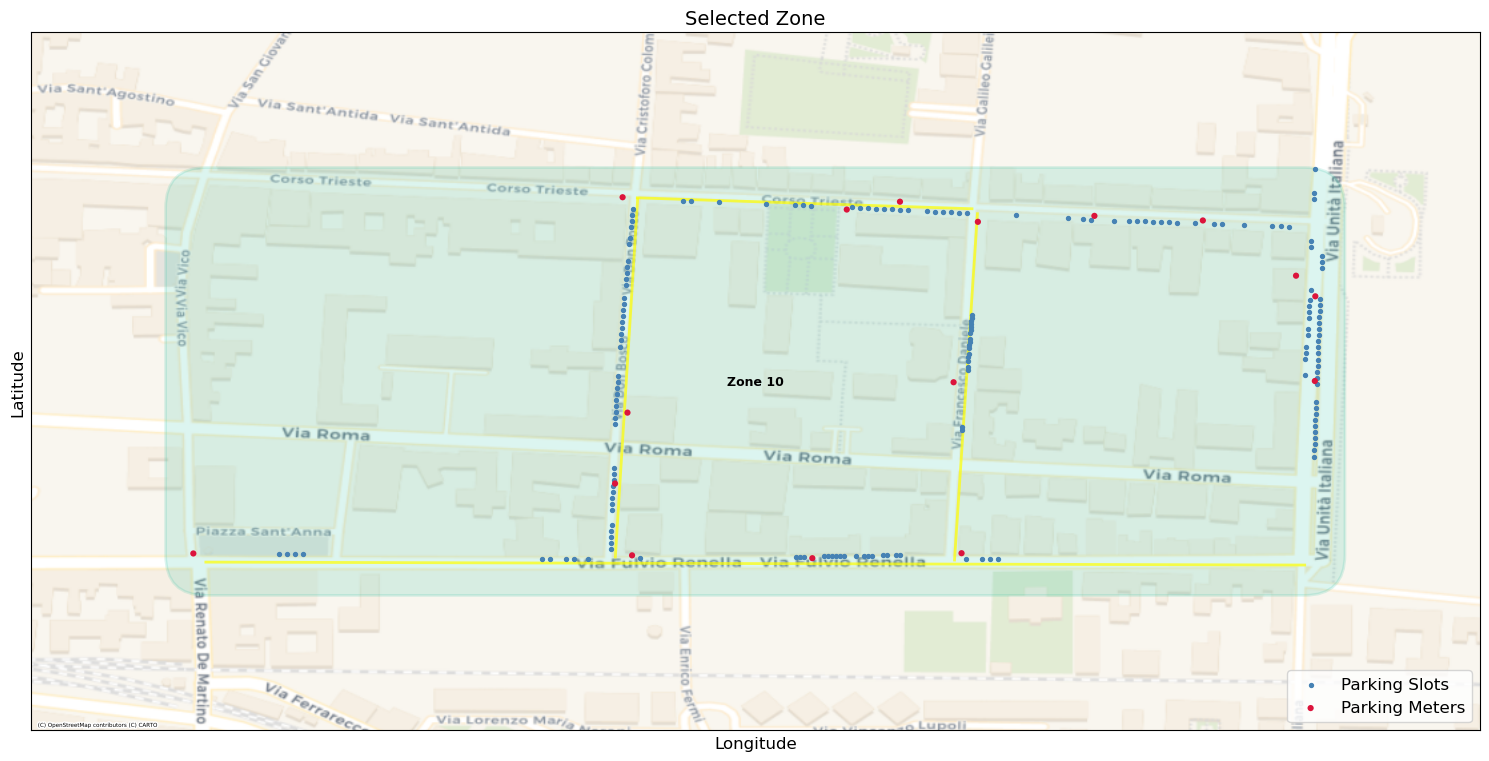

In [5]:
def plot_map(zone_name: str) -> None:
    from src.map import plot_zones, get_map_data, preprocess

    map_path = DATA_PATH / "map"

    data_load: dict[str, Any] = {}

    with open(map_path / "posizioni_parcometri_new.pkl", "rb") as f:
        data_load["parkingmeter_positions"] = pkl.load(f)
    with open(map_path / "roads_gdf.pkl", "rb") as f:
        data_load["roads_gdf"] = pkl.load(f)
    with open(map_path / "stalli_selection_new.pkl", "rb") as f:
        data_load["sensors"] = pkl.load(f)

    map_data = preprocess(data_load, zone_dict)
    parkingmeters_selection = map_data["parkingmeter_positions"]
    slots_selection = map_data["sensors"]
    roads_gdf = map_data["roads_gdf"]

    zone_data = get_map_data(zone, parkingmeters_selection, slots_selection, roads_gdf)

    plot_zones(zone_data, zone_name)


plot_map(**map_args)

## Distribution visualization

### Distribution arguments

- **`zone_name`**: Specifies the name of the zone to visualize.
  Valid values:
  - `"all_map"` ‑ uses all the available zones.
  - `"zone_0"` to `"zone_11"` ‑ uses the corresponding individual zone.
- **`date`**: Specifies the date for the distribution visualization in `YYYY-MM-DD` format.
  Valid dates are from `2025-04-01` to `2025-05-25`.
- **`kind`**: Specifies the type of distribution to visualize.
    Valid values:
    - `"transactions_count"` ‑ visualizes the distribution of transactions count.
    - `"transactions_amount"` ‑ visualizes the distribution of transactions amount.
    - `"occupancy"` ‑ visualizes the distribution of occupancy.
- **`plot_id`**: Specifies the ID of the element to visualize. If `None`, the visualization will be applied to all elements in the specific zone. The element depends on the `kind`:
  - For `transactions_count` and `transactions_amount`, it refers to the parking meter ID.
  - For `occupancy`, it refers to the parking slot ID.
- **`hour_range`**: Specifies the hour range for the visualization.
  Valid values:
  - `None` ‑ visualizes the entire day.
  - `(0, 4)`, `(4, 8)`, `(8, 12)`, `(12, 16)`, `(16, 20)`, `(20, 24)` ‑ visualizes the specified hour range.
- **`legality_status`**: Specifies the legality status for occupancy visualization (only used in case `kind` is `occupancy`).
  Valid values:
    - `None` ‑ visualizes all elements regardless of their legality status.
    - `"occupied_regularly"` ‑ visualizes elements that are occupied regularly.
    - `"occupied_abusively"` ‑ visualizes elements that are occupied abusively.


In [6]:
distrib_args: dict[str, Any] = dict(
    zone_name="all_map",
    date="2025-05-25",
    kind="transactions_count",
    plot_id=None,
    hour_range=None,
    legality_status=None,
)

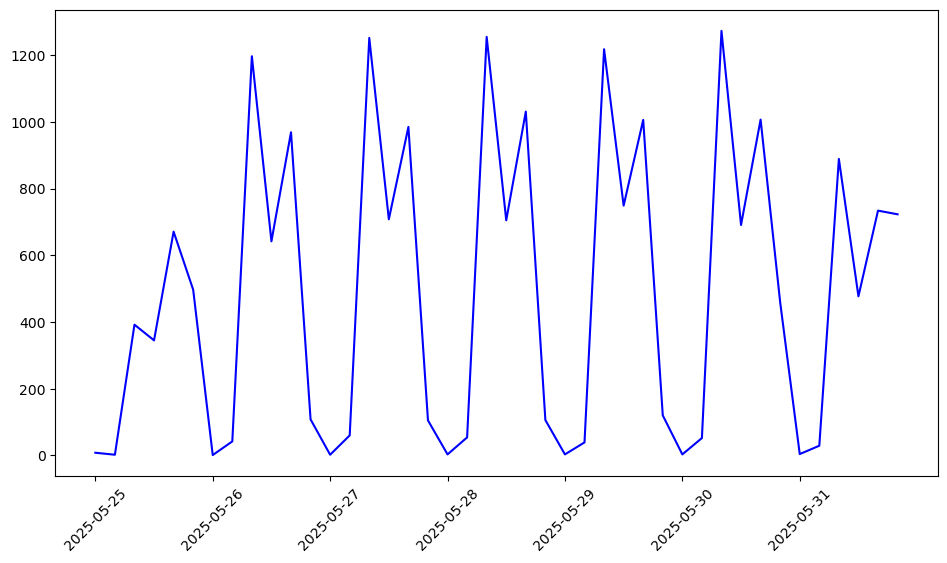

In [7]:
DistribAvailableKinds = Literal[
    "transactions_count",
    "transactions_amount",
    "occupancy",
]

DistribLegalityStatus = Literal["occupied_regularly", "occupied_abusively"]


def plot_distrib(
    kind: DistribAvailableKinds,
    zone_name: str,
    plot_id: int | None,
    date: str,
    hour_range: Sequence[int] | None,
    legality_status: DistribLegalityStatus | None,
) -> None:
    from src.distrib import plot1, plot2, plot3, plot4
    from src.general import build_available_dates

    from typing import get_args

    date_ = pd.to_datetime(  # type: ignore
        date
    )

    available_dates = build_available_dates(transactions_parkingmeters)

    if (
        date_.date() < available_dates["min_date"]
        or date_.date() > available_dates["max_date"]
    ):
        raise ValueError(
            f"Date {date} is out of range. Available dates are from "
            f"{available_dates['min_date'].strftime('%Y-%m-%d')!r} to "
            f"{available_dates['max_date'].strftime('%Y-%m-%d')!r}."
        )

    if kind == "transactions_count" or kind == "transactions_amount":
        if kind == "transactions_count":
            data = transactions_parkingmeters
        elif kind == "transactions_amount":
            data = amount_parkingmeters
        else:
            raise ValueError("Invalid subkind for transactions distribution")
        _ = plot1(
            data,
            zone_dict=zone_dict,
            zone_name=zone_name,
            parkingmeter_id=plot_id,
            date=date_,
            hour_range=hour_range,
            data_type=kind.split("_")[-1],  # 'count' or 'amount'
        )
    elif kind == "occupancy":
        if legality_status is None:
            _ = plot2(
                status_sensors,
                zone_dict=zone_dict,
                zone_name=zone_name,
                parkingslot_id=plot_id,
                date=date_,
                hour_range=hour_range,
            )
        else:
            _ = plot3(
                status_sensors,
                zone_dict=zone_dict,
                zone_name=zone_name,
                parkingslot_id=plot_id,
                date=date_,
                hour_range=hour_range,
                data_type=legality_status,
            )

        if hour_range is None:
            with open(DATA_PATH / "multe_data.pkl", "rb") as f:
                fines_data = pkl.load(f)

            __ = plot4(
                fines_data,
                zone_dict=zone_dict,
                zone_name=zone_name,
                date=date_,
                hour_range=hour_range,
            )
    else:
        raise ValueError(
            f"Invalid kind: {kind}. "
            f"Available kinds are "
            + ", ".join([f"{v!r}" for v in get_args(DistribAvailableKinds)])
            + "."
        )


plot_distrib(**distrib_args)

## Statistics visualization

### Statistics arguments

- **`which_data`**: Specifies the type of data to visualize.
  Valid values:
  - `"correlation_heatmap"` ‑ visualizes the correlation between Abusivism Index vs Number of Fines as two heatmaps: relative vs absolute.
  - `"parkingmeter_analysis"` - prints the analysis of parking meters.
  - `"parkingslot_analysis"` - prints the analysis of parking slots.
  - `"poi_analysis"` - prints the analysis of Points of Interest (POI).
  - `"event_analysis"` - prints the analysis of events.
  - `"abusivism_index"` - prints the analysis of the Abusivism Index.
  - `"fines"` - prints the analysis of fines.
- **`zone_name`**: Specifies the name of the zone to visualize.
    Valid values:
    - `"all_map"` ‑ uses all the available zones.
    - `"zone_0"` to `"zone_11"` ‑ uses the corresponding individual zone.
- **`date`**: Specifies the date for the statistics visualization in `YYYY-MM-DD` format.
  Valid dates are from `2025-04-01` to `2025-05-25`.
- **`hour_range`**: Specifies the hour range for the visualization.
  Valid values:
  - `None` ‑ visualizes the entire day.
  - `(0, 4)`, `(4, 8)`, `(8, 12)`, `(12, 16)`, `(16, 20)`, `(20, 24)` ‑ visualizes the specified hour range.

Note that `"correlation_heatmap"`, `"abusivism_index"` and `"fines"` visualizations are available only when `hour_range` is `None` or one of the following: `(8, 12)`, `(12, 16)`, `(16, 20)`, `(20, 24)`.

In [8]:
stats_args: dict[str, Any] = dict(
    which_data="parkingmeter_analysis",
    zone_name="all_map",
    date="2025-05-20",
    hour_range=(0, 4),
)

In [9]:
StatsWhichData = Literal[
    "correlation_heatmap",
    "parkingmeter_analysis",
    "parkingslot_analysis",
    "poi_analysis",
    "event_analysis",
    "abusivism_index",
    "fines",
]


def plot_stats(
    which_data: StatsWhichData,
    zone_name: str,
    date: str,
    hour_range: Sequence[int] | None,
) -> None:
    from src.stats import get_stats_info, preprocess
    from IPython.display import display  # type: ignore

    data_load: dict[str, Any] = {}

    stats_path = DATA_PATH / "stats"

    with open(stats_path / "event_data.pkl", "rb") as f:
        data_load["events_data"] = pkl.load(f)
    with open(stats_path / "multe_data_tab3.pkl", "rb") as f:
        data_load["multe_data"] = pkl.load(f)
    with open(stats_path / "pois_data.pkl", "rb") as f:
        data_load["poi_data"] = pkl.load(f)
    with open(stats_path / "zone_params.pkl", "rb") as f:
        data_load["zone_params"] = pkl.load(f)

    stats_data = preprocess(data_load)

    date_ = pd.to_datetime(  # type: ignore
        date
    )

    poi_data = stats_data["poi_data"]
    events_data = stats_data["events_data"]
    all_parkingslots = all_sensors
    status_parkingslots = status_sensors
    fines_data = stats_data["multe_data"]
    zone_params = stats_data["zone_params"]

    results, results_abusivisms, correlations, label_map, _ = get_stats_info(
        zone_data=zone,
        mapping_dict=zone_dict,
        poi_data=poi_data,
        events_data=events_data,
        transactions_parkingmeters=transactions_parkingmeters,
        all_parkingslots=all_parkingslots,
        status_parkingslots=status_parkingslots,
        fines_data=fines_data,
        zone_params=zone_params,
        zone_name=zone_name,
        date=date_,
        hour_range=hour_range,
    )

    if which_data == "correlation_heatmap":
        if correlations is None:
            print("No correlations to plot.")
            return
        print("Correlation Heatmap: Abusivism Index vs Number of Fines (relative)")

        display(correlations[0])
        plt.close(correlations[0])

        print("Correlation Heatmap: Abusivism Index vs Number of Fines (absolute)")

        display(correlations[1])
        plt.close(correlations[1])
        return  # the plot will be shown when running the cell

    # in this case, we need to remove the plots
    if correlations is not None:
        plt.close(correlations[0])
        plt.close(correlations[1])

    if which_data == "parkingmeter_analysis":
        out = results[which_data]

        print(f"{label_map[which_data]}:\n")
        key = "number_of_parkingmeters"
        print(f"{label_map[key]}: {out[key]}")
        key = "most_used_parkingmeters"
        if out[key] is not None:
            print(f"{label_map[key]}: {out[key]}")
        key = "least_used_parkingmeters"
        if out[key] is not None:
            print(f"{label_map[key]}: {out[key]}")
    elif which_data == "parkingslot_analysis":
        out = results[which_data]

        print(f"{label_map[which_data]}:\n")
        key = "number_of_parkingslots"
        print(f"{label_map[key]}: {out[key]}")
        key = "most_used_parkingslots"
        if out[key] is not None:
            print(f"{label_map[key]}: {out[key]}")
        key = "least_used_parkingslots"
        if out[key] is not None:
            print(f"{label_map[key]}: {out[key]}")
        key = "average_daily_influx"
        if out[key] is not None:
            print(f"{label_map[key]}: {out[key]}")
    elif which_data == "poi_analysis":
        out = results[which_data]

        print(f"{label_map[which_data]}:\n")
        key = "number_of_poi"
        print(f"{label_map[key]}: {out[key]}")
        key = "number_of_poi_by_category"
        print(f"{label_map[key]}:")
        for subkey, value in out[key].items():
            print(f"\t- {label_map[subkey]}: {value}")
        key = "average_distance_between_parkingmeters_and_poi"
        print(f"{label_map[key]}: {out[key]}")

    elif which_data == "event_analysis":
        out = results[which_data]

        print(f"{label_map[which_data]}:\n")
        key = "number_of_events"
        print(f"{label_map[key]}: {out[key]}")
        key = "number_of_events_by_category"
        print(f"{label_map[key]}:")
        for subkey, value in out[key].items():
            print(f"\t- {label_map[subkey]}: {value}")
        key = "average_distance_between_parkingmeters_and_events"
        print(f"{label_map[key]}: {out[key]}")
        key = "average_daily_events"
        print(f"{label_map[key]}: {out[key]}")
    elif which_data == "abusivism_index":
        if results_abusivisms is None:
            print("No abusivism index to show.")
            return

        out = results_abusivisms[which_data]

        print(f"{label_map[which_data]}:\n")
        for subkey, value in out.items():
            print(f"\t- {label_map[subkey]}: {value}")
    elif which_data == "fines":
        if results_abusivisms is None:
            print("No fines data to show.")
            return

        out = results_abusivisms[which_data]

        print(f"{label_map[which_data]}:\n")
        for subkey, value in out.items():
            print(f"\t- {label_map[subkey]}: {value}")
    else:
        raise ValueError(f"Invalid which_data: {which_data}")


plot_stats(**stats_args)

Parking meter Analysis:

Number of Parking meters: 96
Most Used Parking meters (ID): 77
Least Used Parking meters  (ID): 2


## Agent calendar visualization

### Agent calendar arguments

- **`date`**: Specifies the date for the agent calendar visualization in `YYYY-MM-DD` format.
  Valid dates are from `2025-04-07` to `2025-06-01`.

In [10]:
agent_calendar_args: dict[str, Any] = dict(
    date="2025-06-01",
)

In [11]:
def plot_agent_calendar(date: str) -> None:
    from plotly.offline import init_notebook_mode, iplot  # type: ignore
    from src.agent_calendar import preprocess_calendar, preprocess

    init_notebook_mode(connected=True)

    data_load: dict[str, Any] = {}

    data_load["calendar"] = pd.read_pickle(
        DATA_PATH / "agent_calendar" / "calendar.pkl"
    )

    data = preprocess(data_load)

    agent_calendar = data["calendar"]

    selected_date_ = pd.to_datetime(  # type: ignore
        date
    )

    assert isinstance(selected_date_, pd.Timestamp)

    day_of_week = selected_date_.weekday()

    if day_of_week != 0:
        selected_date_ = selected_date_ - pd.Timedelta(days=day_of_week)

    if selected_date_.date().isoformat() not in agent_calendar:
        raise ValueError(
            f"Selected date {date} is not out of range. "
            f"Valid dates are from {list(agent_calendar.keys())[0]} to {list(agent_calendar.keys())[-1]}."
        )

    fig = preprocess_calendar(agent_calendar, selected_date_, zone)
    iplot(fig)


plot_agent_calendar(**agent_calendar_args)

## Forecasting visualization

### Forecasting arguments

- **`zone_name`**: Specifies the name of the zone to visualize.
  Valid values:
  - `"all_map"` ‑ uses all the available zones.
  - `"zone_0"` to `"zone_11"` ‑ uses the corresponding individual zone.
- **`date`**: Specifies the date for the forecasting visualization in `YYYY-MM-DD` format.
  Valid dates are from `2025-04-01` to `2025-05-25`.
- **`data_type`**: Specifies the type of data to visualize.
  Valid values:
  - `"transactions"` - visualizes the transactions data.
  - `"amount"` - visualizes the amount data.
  - `"roads"` - visualizes the roads data.
- **`parkingmeter_id`**: Specifies the ID of the parking meter to visualize. If `None`, the visualization will be applied to all parking meters in the specific zone. Not applicable when `data_type` is `"roads"`.
- **`road_id`**: Specifies the ID of the road to visualize. If `None`, the visualization will be applied to all roads in the specific zone. Not applicable when `data_type` is `"transactions"` or `"amount"`.

In [12]:
forecast_args: dict[str, Any] = dict(
    zone_name="all_map",
    date="2025-05-25",
    data_type="roads",
    parkingmeter_id=None,
    road_id=None,
)

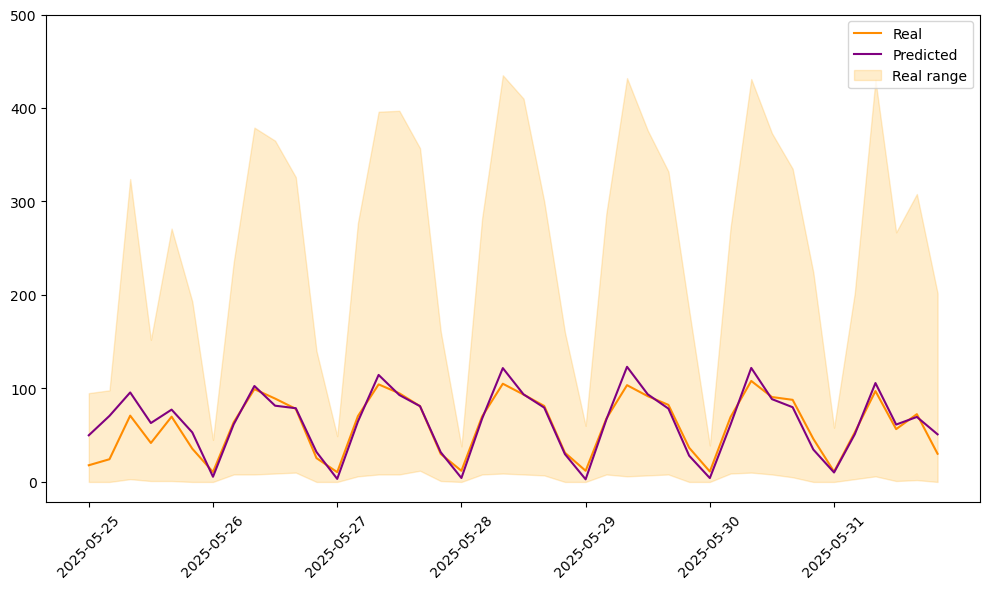

In [13]:
def plot_forecasting(
    zone_name: str,
    date: str,
    data_type: Literal["transactions", "amount", "roads"],
    parkingmeter_id: int | None,
    road_id: int | None,
) -> None:
    from src.forecast import do_get_prediction, preprocess

    forecast_path = DATA_PATH / "forecast"

    data_load: dict[str, Any] = {}

    with open(forecast_path / "events_all.pkl", "rb") as f:
        data_load["events"] = pkl.load(f)
    with open(forecast_path / "transactions_number_parkimeters_all.pkl", "rb") as f:
        data_load["hourlies__transactions"] = pkl.load(f)
    with open(forecast_path / "transactions_amount_parkimeters_all.pkl", "rb") as f:
        data_load["hourlies__amount"] = pkl.load(f)
    with open(forecast_path / "transactions" / "data_scaler.pkl", "rb") as f:
        data_load["data_scalers__transactions"] = pkl.load(f)
    with open(forecast_path / "amount" / "data_scaler.pkl", "rb") as f:
        data_load["data_scalers__amount"] = pkl.load(f)
    with open(forecast_path / "roads" / "data_scaler.pkl", "rb") as f:
        data_load["data_scalers__roads"] = pkl.load(f)
    with open(forecast_path / "transactions" / "exog_scaler.pkl", "rb") as f:
        data_load["exog_scalers__transactions"] = pkl.load(f)
    with open(forecast_path / "amount" / "exog_scaler.pkl", "rb") as f:
        data_load["exog_scalers__amount"] = pkl.load(f)
    with open(forecast_path / "roads" / "exog_scaler.pkl", "rb") as f:
        data_load["exog_scalers__roads"] = pkl.load(f)

    with open(forecast_path / "index_map.json", "r") as f:
        data_load["index_map"] = json.load(f)

    data_load["weather__prec"] = pd.read_csv(  # type: ignore
        forecast_path / "precipitation_all.csv", index_col=0
    )
    data_load["weather__temp"] = pd.read_csv(  # type: ignore
        forecast_path / "temperature_all.csv", index_col=0
    )
    data_load["weather__wind"] = pd.read_csv(  # type: ignore
        forecast_path / "wind_all.csv", index_col=0
    )
    data_load["weather__humidity"] = pd.read_csv(  # type: ignore
        forecast_path / "humidity_all.csv", index_col=0
    )
    data_load["hourlies__roads"] = pd.read_csv(  # type: ignore
        forecast_path / "roads_data.csv", index_col=0
    )
    data_load["poi_dists__parkingmeters"] = pd.read_csv(  # type: ignore
        forecast_path / "distances_poi_new.csv", index_col=0
    )
    data_load["poi_dists__roads"] = pd.read_csv(  # type: ignore
        forecast_path / "distances_poi_strade.csv", index_col=0
    )
    data_load["poi_categories__parkingmeters"] = pd.read_csv(  # type: ignore
        forecast_path / "poi_categories_new.csv", index_col=0
    )
    data_load["poi_categories__roads"] = pd.read_csv(  # type: ignore
        forecast_path / "distances_poi_strade.csv", index_col=0
    )

    data_prepro = preprocess(dict(data=data_load, data_path=forecast_path))

    date_ = pd.to_datetime(  # type: ignore
        date
    )

    out = do_get_prediction(
        zone_name=zone_name,
        date=date_,
        parkingmeter_id=parkingmeter_id
        if data_type in ["transactions", "amount"]
        else None,
        road_id=road_id if data_type == "roads" else None,
        data_type=data_type,
        data=data_prepro,
        zone_dict=zone_dict,
    )

    if isinstance(out, dict):
        raise ValueError(out["error"])


plot_forecasting(**forecast_args)

## What-if visualization

### What-if arguments

- **`scenario`**: Specifies the scenario to visualize.
  Valid values:
  - `"1st"` - visualizes the first scenario (closure of the entire affected zone).
  - `"2nd"` - visualizes the second scenario (installation of a multistory parking facility in the affected zone).
  - `"3rd"` - visualizes the third scenario (three consecutive rainy days).
- **`date`**: Specifies the date for the what-if visualization in `YYYY-MM-DD` format.
  Valid dates are from `2025-03-31` to `2025-05-25`.
- **`affected_zone_name`**: Specifies the name of the zone affected by the what-if scenario.
  Valid values:
  - `"zone_0"` to `"zone_11"` ‑ uses the corresponding individual zone.
- **`data_kind`**: Specifies the type of data to visualize.
  Valid values:
  - `"parkingmeter"` - visualizes the parking meter data.
  - `"parkingslot"` - visualizes the parking slot data.
- **`quantity`**: Specifies the increment of parking slots in the affected zone. Can be a positive integer. Valid only when `scenario` is `"2nd"`. If `None`, it will use the default value of 150 parking slots.
- **`zone_name`**: Specifies the name of the zone to visualize.
    Valid values:
    - `"zone_0"` to `"zone_11"` ‑ uses the corresponding individual zone. All of these zones are valid when `scenario` is `"3rd"`, while for the other scenarios, the closest zones to the affected zone are used. In this case, refer to the reported zones in the next cell.
    - `"all_map"` ‑ uses all the available zones, only valid when `scenario` is `"3rd"`.

In [14]:
with open(DATA_PATH / "whatif" / "vicinity_zone_map.json", "r") as f:
    vicinity_zone_map = json.load(f)
    
print("vicinity zone mapping:")
for zone, vicinity in vicinity_zone_map.items():
    print(f"{zone}: {vicinity}")


vicinity zone mapping:
zone_0: ['zone_1', 'zone_10', 'zone_11']
zone_1: ['zone_0', 'zone_3', 'zone_11']
zone_2: ['zone_6', 'zone_10']
zone_3: ['zone_1', 'zone_6', 'zone_10']
zone_4: ['zone_8']
zone_5: ['zone_8', 'zone_11']
zone_6: ['zone_2', 'zone_3']
zone_7: ['zone_8']
zone_8: ['zone_4', 'zone_5', 'zone_11']
zone_9: ['zone_1', 'zone_3']
zone_10: ['zone_0', 'zone_2', 'zone_3', 'zone_6']
zone_11: ['zone_0', 'zone_1', 'zone_5', 'zone_8']


In [15]:
whatif_args: dict[str, Any] = dict(
    scenario="1st",
    date="2025-05-25",
    affected_zone_name="zone_0",
    quantity=None,
    data_kind="parkingmeter",
    zone_name="zone_1",
)

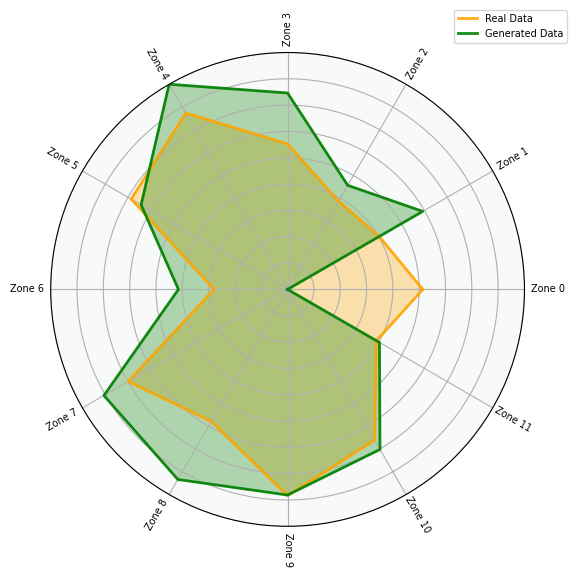

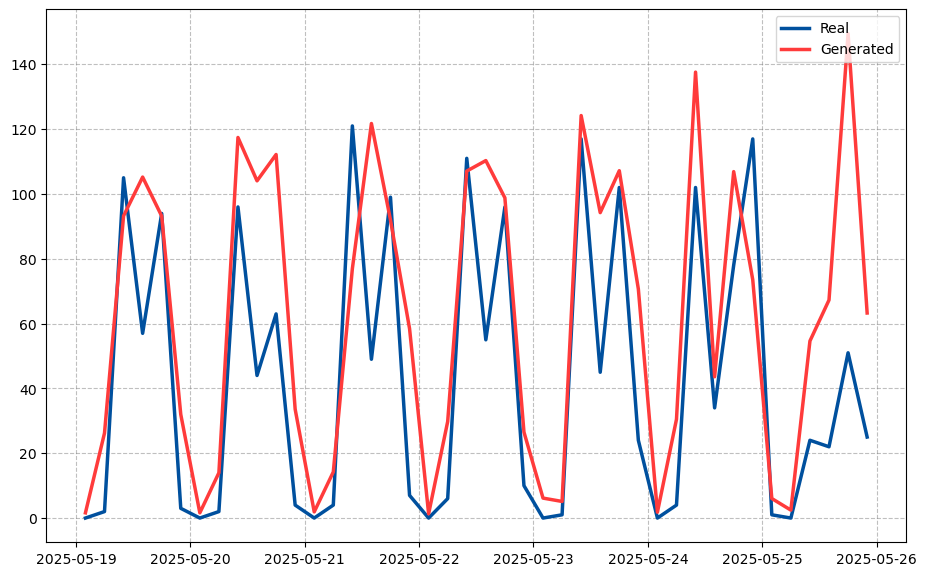

In [16]:
def plot_whatif(
    scenario: Literal["1st", "2nd", "3rd"],
    date: str,
    affected_zone_name: str,
    quantity: int | None,
    data_kind: Literal["parkingmeter", "parkingslot"],
    zone_name: str,
) -> None:
    from typing import cast

    from numpy.typing import NDArray
    from src.whatif import (
        create_cumulative_plot,
        create_radar_chart_map,
        do_get_generation,
        prepare_generated_data,
        preprocess,
    )

    if scenario not in ["1st", "2nd", "3rd"]:
        raise ValueError(
            f"Invalid scenario: {scenario}. "
            "Available scenarios are '1st', '2nd', and '3rd'."
        )

    if affected_zone_name == "all_map" or affected_zone_name not in zone_dict:
        raise ValueError(
            f"Invalid affected_zone_name: {affected_zone_name}. "
            "It should be a valid single zone name."
        )

    if data_kind not in ["parkingmeter", "parkingslot"]:
        raise ValueError(
            f"Invalid data_kind: {data_kind}. "
            "Available data kinds are 'parkingmeter' and 'parkingslot'."
        )

    FloatArray = NDArray[np.float32]

    whatif_path = DATA_PATH / "whatif"

    data_load: dict[str, Any] = {}

    with open(whatif_path / "1st" / "input" / "final_parkingmeters.pkl", "rb") as f:
        data_load["final_parkingmeters__1st"] = pkl.load(f)
    with open(whatif_path / "1st" / "input" / "final_parkingslots.pkl", "rb") as f:
        data_load["final_parkingslots__1st"] = pkl.load(f)
    with open(whatif_path / "1st" / "input" / "p_coords.pkl", "rb") as f:
        data_load["p_coordinates__1st"] = pkl.load(f)
    with open(whatif_path / "1st" / "input" / "p_scaler.pkl", "rb") as f:
        data_load["p_scaler__1st"] = pkl.load(f)
    with open(whatif_path / "1st" / "input" / "s_coords.pkl", "rb") as f:
        data_load["s_coordinates__1st"] = pkl.load(f)
    with open(whatif_path / "1st" / "input" / "s_scaler.pkl", "rb") as f:
        data_load["s_scaler__1st"] = pkl.load(f)
    with open(whatif_path / "2nd" / "input" / "final_parkingslots.pkl", "rb") as f:
        data_load["final_parkingslots__2nd"] = pkl.load(f)
    with open(whatif_path / "2nd" / "input" / "s_coords.pkl", "rb") as f:
        data_load["s_coordinates__2nd"] = pkl.load(f)
    with open(whatif_path / "2nd" / "input" / "s_scaler.pkl", "rb") as f:
        data_load["s_scaler__2nd"] = pkl.load(f)
    with open(whatif_path / "2nd" / "input" / "road_dict.pkl", "rb") as f:
        data_load["road_dict__2nd"] = pkl.load(f)
    with open(whatif_path / "3rd" / "input" / "final_parkingmeters.pkl", "rb") as f:
        data_load["final_parkingmeters__3rd"] = pkl.load(f)
    with open(whatif_path / "3rd" / "input" / "final_parkingslots.pkl", "rb") as f:
        data_load["final_parkingslots__3rd"] = pkl.load(f)
    with open(whatif_path / "3rd" / "input" / "p_coords.pkl", "rb") as f:
        data_load["p_coordinates__3rd"] = pkl.load(f)
    with open(whatif_path / "3rd" / "input" / "p_scaler.pkl", "rb") as f:
        data_load["p_scaler__3rd"] = pkl.load(f)
    with open(whatif_path / "3rd" / "input" / "s_coords.pkl", "rb") as f:
        data_load["s_coordinates__3rd"] = pkl.load(f)
    with open(whatif_path / "3rd" / "input" / "s_scaler.pkl", "rb") as f:
        data_load["s_scaler__3rd"] = pkl.load(f)

    with open(whatif_path / "distances_p.json", "r") as f:
        data_load["distances_p"] = json.load(f)
    with open(whatif_path / "distances_s.json", "r") as f:
        data_load["distances_s"] = json.load(f)
    with open(whatif_path / "vicinity_zone_map.json", "r") as f:
        data_load["dict_zone"] = json.load(f)

    data_load["weather_data__3rd"] = pd.read_csv(  # type: ignore
        whatif_path / "3rd" / "input" / "data_meteo_4h.csv", index_col="date"
    )

    whatif_data = preprocess(dict(data_path=whatif_path, data=data_load))

    zones = [zone for zone in zone_dict.keys() if zone != "all_map"]

    data = whatif_data["data"]
    data_path = whatif_data["data_path"]

    date_ = pd.to_datetime(  # type: ignore
        date
    )

    start_date = data["start_date"]
    end_date = data["end_date"]

    if (
        date_.date()
        < pd.to_datetime(  # type: ignore
            start_date
        ).date()
        or date_.date()
        > pd.to_datetime(  # type: ignore
            end_date
        ).date()
    ):
        raise ValueError(
            f"Date {date} is out of range. "
            f"Available dates are from {start_date} to {end_date}."
        )

    _, output, data_key = do_get_generation(
        scenario, date_, affected_zone_name, quantity, data_path, data, zone_dict, zones
    )

    data_real_t = data_key["data"]
    data_real_t = data_real_t.permute(0, 2, 1, 3, 4)
    data_real = cast(
        FloatArray,
        data_real_t.numpy(),  # type: ignore
    )

    if scenario != "3rd":
        dict_zone = data["dict_zone"]
        dictionary = dict_zone[affected_zone_name]
    else:
        dictionary = ["all_map"] + zones

    out_data = prepare_generated_data(
        scenario,
        affected_zone_name,
        output,
        data_real,
        dictionary,
        data,
    )

    _ = create_radar_chart_map(scenario, out_data, data_kind, zone_dict)

    _ = create_cumulative_plot(
        scenario, data_key["start_date"], out_data, data_kind, zone_name, zone_dict
    )


plot_whatif(**whatif_args)